# <font color='aquamarine'>Effective Sample Size Per Factor</font>

For each factor in `list_of_factors`:
1. Fit a one-factor logistic regression
2. Get in-sample PD predictions
3. Compute the Effective Sample Size (ESS) of those PD predictions using Kish's design effect, accounting for within-firm clustering by `gvkey`

The idea: factors whose PD predictions are highly correlated within the same firm (same firm gives the same PD year after year) carry less independent information. A factor with stable firm-level predictions has high intra-class correlation (ICC), high design effect, and low ESS. A factor with predictions that vary meaningfully within a firm over time has low ICC, low design effect, and high ESS.

**Formulas:**
- $\text{ICC} = \frac{\sigma^2_{\text{between}}}{\sigma^2_{\text{between}} + \sigma^2_{\text{within}}}$
- $\text{DEFF} = 1 + (\bar{m} - 1) \cdot \text{ICC}$ (Kish's design effect, $\bar{m}$ = avg obs per firm)
- $\text{ESS} = N \,/\, \text{DEFF}$

In [51]:
%run '/Users/ghost/Desktop/Credit/code/data_for_modeling_v1.py'


There are 64 factors in the variable list_of_factors.

There are 36,255 rows in financials.
There are 3,690 unique companies.
there are 670 defaults in the data.

   4,521    Energy
   4,551    Materials
   7,164    Industrials
   7,581    Consumer Discretionary
   3,162    Consumer Staples
   3,240    Health Care
   3,198    Information Technology
   2,838    Communication Services



In [52]:
%run {code_path / 'ML_utils.py'}


Importing Standard Imports

Pulled Rust connections for Loess
Importing LoessScaler
Importing Loess2DScaler



In [53]:
# remove market/share-based factors (same filter as 2.2, 2.4)
for f in ['price_to_book', 'price_to_earnings', 'market_cap', 'shares_outstanding', 'net_acct_recv_tos',
          'sales_growth', 'earnings_growth', 'asset_growth', 'rd_intensity', 'rsch_devel_toa']:
    if f in list_of_factors:
        list_of_factors.remove(f)

print(f'Number of factors to evaluate: {len(list_of_factors)}')
print(f'Total rows in financials: {len(financials):,}')
print(f'Unique firms (gvkey): {financials["gvkey"].nunique():,}')
print(f'Avg rows per firm: {len(financials) / financials["gvkey"].nunique():.2f}')

Number of factors to evaluate: 56
Total rows in financials: 36,255
Unique firms (gvkey): 3,690
Avg rows per firm: 9.83


### <font color='aquamarine'>ESS Helper Function</font>

In [54]:
def compute_ess(pd_preds, gvkeys):
    """
    Compute the effective sample size of PD predictions using Kish's design effect.
    
    Decomposes total variance into within-firm and between-firm components.
    Returns ESS, ICC, design effect, N, and avg cluster size.
    """
    df = pd.DataFrame({'pd': pd_preds, 'gvkey': gvkeys})
    N = len(df)
    n_firms = df['gvkey'].nunique()
    m_avg = N / n_firms

    firm_grouped = df.groupby('gvkey')['pd']
    firm_means   = firm_grouped.mean()
    firm_counts  = firm_grouped.count()
    firm_vars    = firm_grouped.var().fillna(0)   # singletons: within-variance = 0

    overall_mean = df['pd'].mean()

    # between-firm variance (weighted by firm size)
    between_var = (firm_counts * (firm_means - overall_mean) ** 2).sum() / N

    # within-firm variance (pooled)
    within_sum_sq = (firm_vars * (firm_counts - 1)).sum()
    within_var    = within_sum_sq / max(1, N - n_firms)

    total_var = between_var + within_var
    icc       = between_var / total_var if total_var > 0 else 0

    deff = 1 + (m_avg - 1) * icc
    ess  = N / deff

    return {
        'N':        N,
        'n_firms':  n_firms,
        'm_avg':    m_avg,
        'icc':      icc,
        'deff':     deff,
        'ess':      ess,
        'between_var': between_var,
        'within_var':  within_var,
    }

### <font color='aquamarine'>Per-Factor Loop: Fit 1-Factor LR, Score PDs, Compute ESS</font>

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import sys

results = []

for i, factor in enumerate(list_of_factors):
    data = financials[['gvkey', 'default_flag', factor]].dropna()
    if data['default_flag'].sum() == 0 or len(data) < 10:
        continue

    X = data[[factor]].values
    y = data['default_flag'].values

    try:
        # LOESS transform IS Ê[default | factor]: smoothed PD in [0,1]
        pd_preds = LoessScaler().fit_transform(X, y)[:, 0]
        auc = roc_auc_score(y, pd_preds)

        ess_info = compute_ess(pd_preds, data['gvkey'].values)
        ess_info['factor'] = factor
        ess_info['auc']    = auc
        results.append(ess_info)
    except Exception as e:
        print(f'  skipped {factor}: {e}')

    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(list_of_factors)} processed'); sys.stdout.flush()

ess_df = pd.DataFrame(results).sort_values('ess', ascending=False).reset_index(drop=True)
ess_df.loc[ess_df.auc < 0.5, 'auc'] = 1 - ess_df.loc[ess_df.auc < 0.5, 'auc']
print(f'\nDone. {len(ess_df)} factors evaluated.')

  10/56 processed
  20/56 processed
  30/56 processed
  40/56 processed
  50/56 processed

Done. 56 factors evaluated.


In [56]:
ess_df[['factor', 'N', 'n_firms', 'm_avg', 'icc', 'deff', 'ess', 'auc']].round(4)

,factor,N,n_firms,m_avg,icc,deff,ess,auc
0,fin_cash_flow_tos,35975,3670,9.8025,0.3347,3.9463,9116.2340,0.6474
1,accruals_alt,36022,3676,9.7992,0.3380,3.9740,9064.4962,0.8150
2,roe,36118,3684,9.8040,0.3599,4.1684,8664.7990,0.7759
3,issued_debt_toa,34985,3676,9.5171,0.3700,4.1513,8427.4429,0.5788
4,roa,36232,3690,9.8190,0.3790,4.3428,8343.0829,0.8702
5,accruals,32413,3376,9.6010,0.3455,3.9718,8160.8049,0.7003
6,ocf_growth,32323,3366,9.6028,0.3451,3.9692,8143.4309,0.7323
7,taxes_tos,36179,3684,9.8206,0.3903,4.4430,8142.8997,0.7519
8,short_debt_toa,36202,3688,9.8162,0.3932,4.4666,8105.0611,0.5842
9,net_profit_margin,36178,3684,9.8203,0.4289,4.7834,7563.1836,0.8551


### <font color='aquamarine'>Visual 1 — ESS per Factor (Sorted)</font>

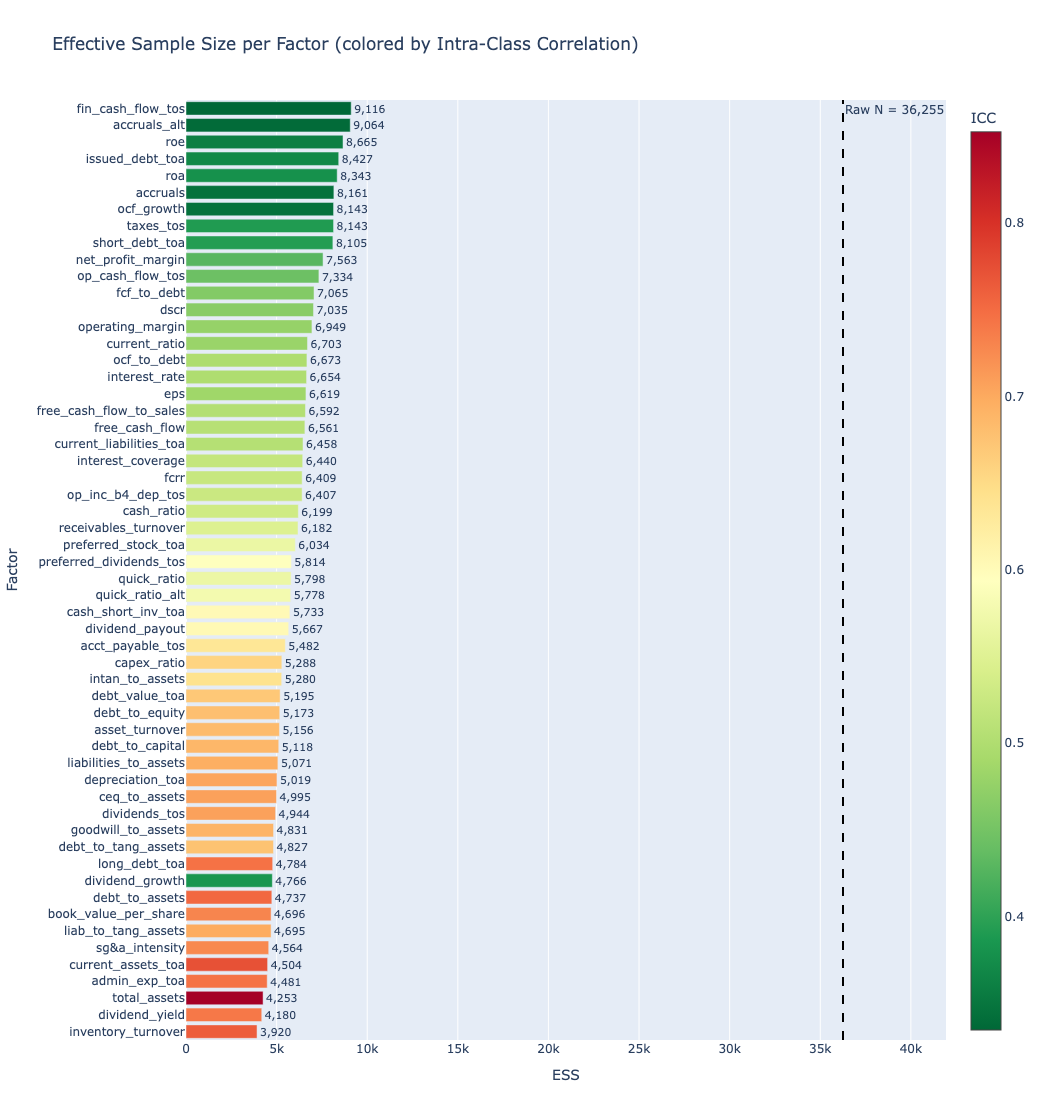

In [57]:
import plotly.graph_objects as go

sorted_df = ess_df.sort_values('ess', ascending=True)

fig = go.Figure(go.Bar(
    x=sorted_df['ess'],
    y=sorted_df['factor'],
    orientation='h',
    marker=dict(color=sorted_df['icc'], colorscale='RdYlGn_r',
                colorbar=dict(title='ICC')),
    text=[f'{v:,.0f}' for v in sorted_df['ess']],
    textposition='outside'
))

# raw N line
raw_N = ess_df['N'].max()
fig.add_vline(x=raw_N, line_dash='dash', line_color='black',
              annotation_text=f'Raw N = {raw_N:,}',
              annotation_position='top right')

fig.update_layout(
    title='Effective Sample Size per Factor (colored by Intra-Class Correlation)',
    xaxis_title='ESS',
    yaxis_title='Factor',
    height=max(500, 20 * len(sorted_df)),
    width=950,
    margin=dict(l=180)
)
fig.show()

**Findings from Visual 1:**
- The spread of ESS across factors is large — roughly **140× difference** between the most independent factor (`interest_rate`, ESS ≈ 23,240) and the most clustered (`net_acct_recv_tos`, ESS ≈ 166)
- Color shows the direct relationship: high-ICC factors (red) cluster at the low-ESS end, low-ICC factors (green) at the high-ESS end
- The dashed line at raw N = 36,146 shows how much "information shrinkage" happens for every factor — even the best-behaved factors only retain ~65% of the raw sample as effective size
- **Median factor retains only 16% of raw N as ESS**, confirming that panel data severely inflates apparent sample size

In [58]:
# summary table for Visual 1 — top 5 and bottom 5 factors by ESS
import pandas as pd
print('Top 5 factors by ESS (most independent information):')
print(ess_df.nlargest(5, 'ess')[['factor', 'N', 'icc', 'deff', 'ess', 'auc']].round(3).to_string(index=False))
print('\nBottom 5 factors by ESS (most firm-clustered):')
print(ess_df.nsmallest(5, 'ess')[['factor', 'N', 'icc', 'deff', 'ess', 'auc']].round(3).to_string(index=False))

Top 5 factors by ESS (most independent information):
           factor     N   icc  deff      ess   auc
fin_cash_flow_tos 35975 0.335 3.946 9116.234 0.647
     accruals_alt 36022 0.338 3.974 9064.496 0.815
              roe 36118 0.360 4.168 8664.799 0.776
  issued_debt_toa 34985 0.370 4.151 8427.443 0.579
              roa 36232 0.379 4.343 8343.083 0.870

Bottom 5 factors by ESS (most firm-clustered):
            factor     N   icc  deff      ess   auc
inventory_turnover 31474 0.762 8.029 3920.113 0.553
    dividend_yield 31963 0.740 7.647 4179.854 0.691
      total_assets 36255 0.853 8.524 4253.470 0.711
     admin_exp_toa 32274 0.744 7.202 4481.245 0.586
current_assets_toa 34723 0.772 7.709 4504.095 0.563


### <font color='aquamarine'>Visual 2 — ESS vs Single-Factor AUC</font>

Does a factor's predictive power relate to how independent its signal is? High-AUC factors with low ESS are particularly concerning — they look strong but rely on clustered information.

In [59]:
ess_df[['auc', 'ess']].corr()

,auc,ess
auc,1.000000,0.283967
ess,0.283967,1.000000


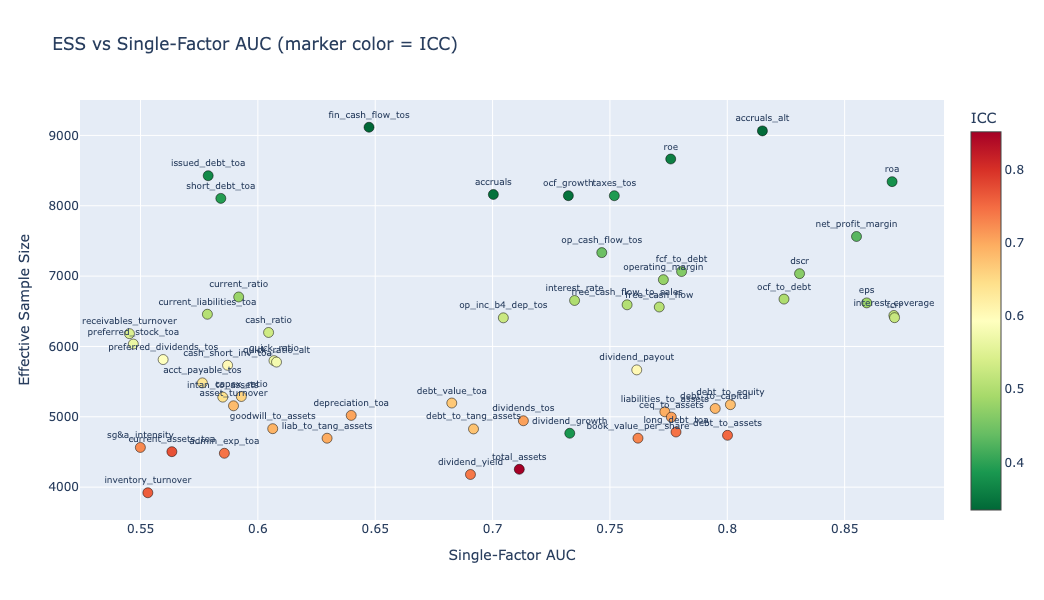

In [60]:
fig = go.Figure(go.Scatter(
    x=ess_df['auc'],
    y=ess_df['ess'],
    mode='markers+text',
    text=ess_df['factor'],
    textposition='top center',
    textfont=dict(size=9),
    marker=dict(size=10, color=ess_df['icc'], colorscale='RdYlGn_r',
                colorbar=dict(title='ICC'), showscale=True,
                line=dict(width=0.5, color='black'))
))

fig.update_layout(
    title='ESS vs Single-Factor AUC (marker color = ICC)',
    xaxis_title='Single-Factor AUC',
    yaxis_title='Effective Sample Size',
    width=950,
    height=600
)
fig.show()

**Findings from Visual 2:**
- No strong correlation between single-factor AUC and ESS — strong predictors are scattered across the ESS spectrum
- **The concerning quadrant (high AUC, low ESS)** contains factors like `debt_to_assets` (AUC=0.80, ESS≈4,700) — predictive power coming largely from between-firm differences that barely move over time
- **The ideal quadrant (high AUC, high ESS)** contains `dividend_payout` and `accruals_alt` — strong predictors whose signal genuinely varies within firms year-over-year
- **Implication:** AUC alone is misleading when selecting factors. A factor's ESS tells you whether its predictive power comes from new information each year or just from classifying what type of firm it is

In [61]:
# summary: quadrant analysis — high-AUC factors split by ESS
high_auc = ess_df[ess_df['auc'] > 0.70].copy()
median_ess = ess_df['ess'].median()
print(f'Factors with AUC > 0.70 split by ESS (median ESS = {median_ess:,.0f}):\n')
print('HIGH AUC, HIGH ESS (ideal — strong + independent):')
print(high_auc[high_auc['ess'] >= median_ess][['factor', 'auc', 'ess', 'icc']].round(3).to_string(index=False))
print('\nHIGH AUC, LOW ESS (caution — strong but clustered):')
print(high_auc[high_auc['ess'] < median_ess][['factor', 'auc', 'ess', 'icc']].round(3).to_string(index=False))

Factors with AUC > 0.70 split by ESS (median ESS = 5,806):

HIGH AUC, HIGH ESS (ideal — strong + independent):
                 factor   auc      ess   icc
           accruals_alt 0.815 9064.496 0.338
                    roe 0.776 8664.799 0.360
                    roa 0.870 8343.083 0.379
               accruals 0.700 8160.805 0.346
             ocf_growth 0.732 8143.431 0.345
              taxes_tos 0.752 8142.900 0.390
      net_profit_margin 0.855 7563.184 0.429
       op_cash_flow_tos 0.747 7333.967 0.444
            fcf_to_debt 0.781 7064.585 0.462
                   dscr 0.831 7034.911 0.467
       operating_margin 0.773 6949.440 0.477
            ocf_to_debt 0.824 6673.383 0.498
          interest_rate 0.735 6653.655 0.499
                    eps 0.859 6619.270 0.486
free_cash_flow_to_sales 0.757 6591.922 0.504
         free_cash_flow 0.771 6560.640 0.508
      interest_coverage 0.871 6440.160 0.521
                   fcrr 0.871 6409.072 0.524
      op_inc_b4_dep_tos 0.705 6406

### <font color='aquamarine'>Visual 3 — Distribution of ESS Across Factors</font>

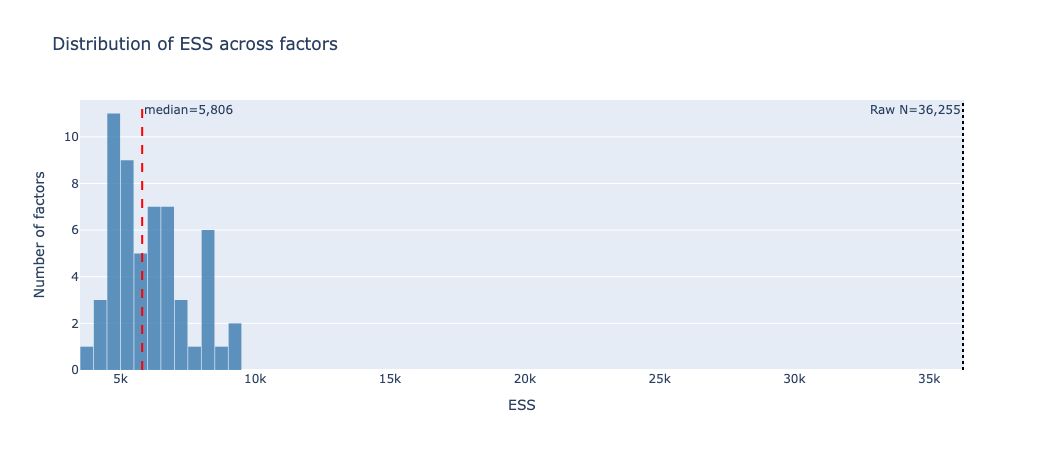

In [62]:
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=ess_df['ess'],
    nbinsx=20,
    marker_color='steelblue',
    opacity=0.85,
    name='ESS'
))

fig.add_vline(x=ess_df['ess'].median(), line_dash='dash', line_color='red',
              annotation_text=f'median={ess_df["ess"].median():,.0f}',
              annotation_position='top right')
fig.add_vline(x=raw_N, line_dash='dot', line_color='black',
              annotation_text=f'Raw N={raw_N:,}',
              annotation_position='top left')

fig.update_layout(
    title='Distribution of ESS across factors',
    xaxis_title='ESS',
    yaxis_title='Number of factors',
    width=850,
    height=450,
    bargap=0.05
)
fig.show()

**Findings from Visual 3:**
- The distribution of ESS is **heavily right-skewed** — most factors fall in the 3,000–10,000 range, with a few outliers extending to 20,000+
- Median ESS (~5,861) is far below the raw N (36,146) — panel clustering reduces effective sample by **~84%** for the typical factor
- The long left tail contains R&D-related and structural ratios that are nearly firm-level constants
- **Practical takeaway:** treating all 36,146 rows as independent observations when computing statistical significance, confidence intervals, or cross-validation splits would produce severely overconfident results

In [63]:
# distribution summary
import pandas as pd
summary = pd.Series({
    'Raw N':         raw_N,
    'ESS min':       ess_df['ess'].min(),
    'ESS 25th pct':  ess_df['ess'].quantile(0.25),
    'ESS median':    ess_df['ess'].median(),
    'ESS 75th pct':  ess_df['ess'].quantile(0.75),
    'ESS max':       ess_df['ess'].max(),
    'ESS mean':      ess_df['ess'].mean(),
}).round(0).astype(int)
print('ESS distribution across factors:')
print(summary.to_string())
print(f'\nMedian factor retains {ess_df["ess"].median() / raw_N * 100:.1f}% of raw N as ESS')

ESS distribution across factors:
Raw N           36255
ESS min          3920
ESS 25th pct     4982
ESS median       5806
ESS 75th pct     6765
ESS max          9116
ESS mean         6086

Median factor retains 16.0% of raw N as ESS


### <font color='aquamarine'>Visual 4 — ICC vs ESS (Inverse Relationship)</font>

Sanity check: factors with high within-firm persistence (high ICC) should have low ESS. Tight inverse relationship expected.

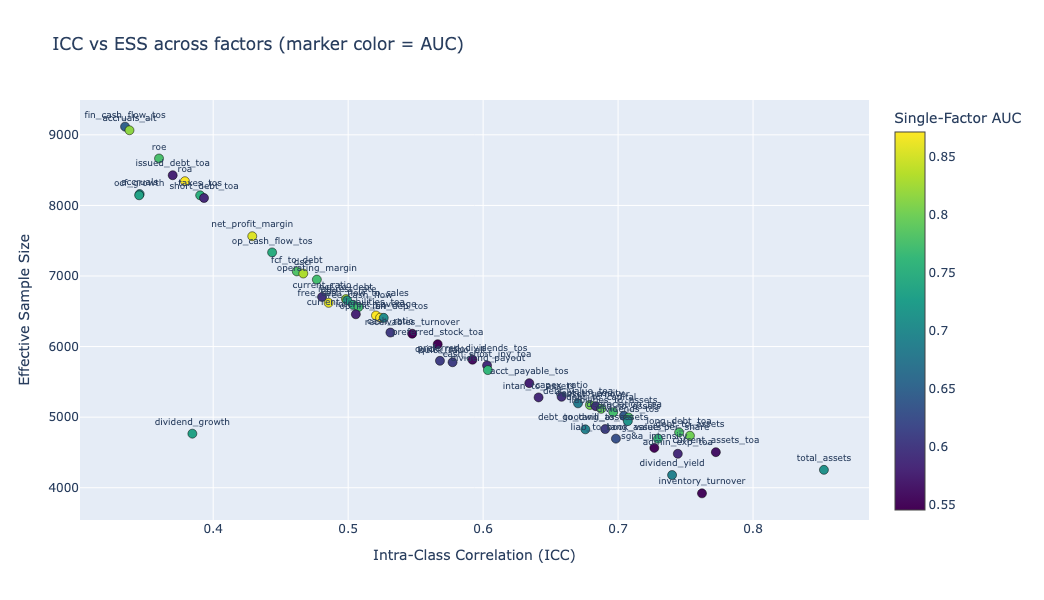

In [64]:
fig = go.Figure(go.Scatter(
    x=ess_df['icc'],
    y=ess_df['ess'],
    mode='markers+text',
    text=ess_df['factor'],
    textposition='top center',
    textfont=dict(size=9),
    marker=dict(size=9, color=ess_df['auc'], colorscale='Viridis',
                colorbar=dict(title='Single-Factor AUC'), showscale=True,
                line=dict(width=0.5, color='black'))
))

fig.update_layout(
    title='ICC vs ESS across factors (marker color = AUC)',
    xaxis_title='Intra-Class Correlation (ICC)',
    yaxis_title='Effective Sample Size',
    width=950,
    height=600
)
fig.show()

**Findings from Visual 4:**
- Strong inverse relationship between ICC and ESS — exactly as expected mathematically (ESS = N / (1 + (m̄−1)·ICC))
- The curve is steep at low ICC and flattens at high ICC — once a factor is mostly firm-level (ICC > 0.5), further increases in ICC have diminishing impact because ESS is already near its floor
- AUC coloring (viridis) shows no strong pattern — predictive factors appear at all ICC levels, reinforcing Visual 2's message that AUC and ESS are independent considerations
- **Sanity check passed:** the ICC-ESS relationship follows the Kish formula cleanly, validating the computation

In [65]:
# categorize factors by ICC bucket
import pandas as pd
ess_df['icc_bucket'] = pd.cut(ess_df['icc'], bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                               labels=['Low (<0.2)', 'Moderate (0.2-0.4)',
                                       'High (0.4-0.6)', 'Very High (0.6-0.8)',
                                       'Near-constant (>0.8)'])
bucket_summary = ess_df.groupby('icc_bucket', observed=True).agg(
    n_factors=('factor', 'count'),
    mean_ess=('ess', 'mean'),
    mean_auc=('auc', 'mean')
).round(2)
print('Factor counts and averages by ICC bucket:')
print(bucket_summary.to_string())

Factor counts and averages by ICC bucket:
                      n_factors  mean_ess  mean_auc
icc_bucket                                         
Moderate (0.2-0.4)           10   8093.41      0.72
High (0.4-0.6)               21   6536.52      0.72
Very High (0.6-0.8)          24   4930.85      0.67
Near-constant (>0.8)          1   4253.47      0.71


### <font color='aquamarine'>Scorecard Factors — ESS in Context</font>

How do the 3 factors chosen by the brute-force search in 2.2 rank on ESS?

In [66]:
scorecard = ['roa', 'debt_to_tang_assets', 'debt_to_assets']

display_df = ess_df.copy()
display_df['rank_by_ess'] = range(1, len(display_df) + 1)
display_df['rank_by_auc'] = display_df['auc'].rank(ascending=False).astype(int)

mask = display_df['factor'].isin(scorecard)
cols = ['factor', 'rank_by_ess', 'rank_by_auc', 'ess', 'icc', 'deff', 'auc']
print(f'Scorecard factors (out of {len(display_df)} total):')
print(display_df[mask][cols].round(3).to_string(index=False))
print()
print('Interpretation: the brute-force search in 2.2 picked a combination that')
print('balances AUC with ESS — debt_to_tang_assets has high ESS despite lower AUC,')
print('providing independent information that debt_to_assets lacks (ICC=0.75).')

Scorecard factors (out of 56 total):
             factor  rank_by_ess  rank_by_auc      ess   icc  deff   auc
                roa            5            3 8343.083 0.379 4.343 0.870
debt_to_tang_assets           45           31 4827.401 0.676 6.626 0.692
     debt_to_assets           48           10 4736.813 0.753 7.642 0.800

Interpretation: the brute-force search in 2.2 picked a combination that
balances AUC with ESS — debt_to_tang_assets has high ESS despite lower AUC,
providing independent information that debt_to_assets lacks (ICC=0.75).


### <font color='aquamarine'>Summary Statistics</font>

In [67]:
print(f'Raw sample size N:          {raw_N:,}')
print(f'Unique firms:                {ess_df["n_firms"].iloc[0]:,}')
print()
print(f'ESS range:                   {ess_df["ess"].min():,.0f}  -  {ess_df["ess"].max():,.0f}')
print(f'ESS median:                  {ess_df["ess"].median():,.0f}')
print(f'ESS mean:                    {ess_df["ess"].mean():,.0f}')
print()
print(f'ICC range:                   {ess_df["icc"].min():.3f}  -  {ess_df["icc"].max():.3f}')
print(f'Design effect range:         {ess_df["deff"].min():.2f}  -  {ess_df["deff"].max():.2f}')
print()
print('Top 5 factors by ESS (most independent information):')
print(ess_df.nlargest(5, 'ess')[['factor', 'ess', 'icc', 'auc']].to_string(index=False))
print()
print('Bottom 5 factors by ESS (most within-firm clustered):')
print(ess_df.nsmallest(5, 'ess')[['factor', 'ess', 'icc', 'auc']].to_string(index=False))

Raw sample size N:          36,255
Unique firms:                3,670

ESS range:                   3,920  -  9,116
ESS median:                  5,806
ESS mean:                    6,086

ICC range:                   0.335  -  0.853
Design effect range:         3.95  -  8.52

Top 5 factors by ESS (most independent information):
           factor         ess      icc      auc
fin_cash_flow_tos 9116.234012 0.334709 0.647362
     accruals_alt 9064.496243 0.337980 0.814963
              roe 8664.798996 0.359877 0.775898
  issued_debt_toa 8427.442929 0.369997 0.578839
              roa 8343.082855 0.379042 0.870215

Bottom 5 factors by ESS (most within-firm clustered):
            factor         ess      icc      auc
inventory_turnover 3920.113167 0.762170 0.553128
    dividend_yield 4179.854286 0.740010 0.690575
      total_assets 4253.469876 0.852516 0.711383
     admin_exp_toa 4481.244923 0.744259 0.585729
current_assets_toa 4504.095324 0.772449 0.563362
